# Graham Number（格雷厄姆数）估值教程

本教程将带你深入了解 **Graham Number** 估值方法——本杰明·格雷厄姆为防御型投资者设计的经典公式。

## 学习目标

1. 理解 Graham Number 的核心原理和推导过程
2. 掌握公式的适用条件和局限性
3. 使用 `valueinvest` 库获取真实数据并估值
4. 手动计算每一步，理解公式背后的逻辑
5. 对比不同公司的 Graham Number 结果
6. 理解资产轻公司为何不适用此方法

---

> 本教程使用 [ValueInvest](https://github.com/wangzhe3224/valueinvest) 库

## 1. Graham Number 基础概念

### 什么是 Graham Number？

Graham Number 是本杰明·格雷厄姆在《聪明的投资者》中提出的估值指标，专门为**防御型投资者**设计。

核心思想：一家公司的合理股价应该同时满足**市盈率（P/E）**和**市净率（P/B）**都不过高。

### 格雷厄姆的防御型投资标准

格雷厄姆认为防御型投资者应该满足：
- **P/E ≤ 15**（市盈率不超过 15 倍）
- **P/B ≤ 1.5**（市净率不超过 1.5 倍）
- **P/E × P/B ≤ 22.5**（两者乘积不超过 22.5）

### 核心公式推导

从 P/E × P/B ≤ 22.5 出发：

$$\frac{P}{E} \times \frac{P}{B} \leq 22.5$$

展开得：

$$\frac{P^2}{E \times B} \leq 22.5$$

因此最大合理价格：

$$P \leq \sqrt{22.5 \times EPS \times BVPS}$$

其中：
- $EPS$ = 每股收益（Earnings Per Share）
- $BVPS$ = 每股净资产（Book Value Per Share）
- 22.5 = 15 × 1.5（P/E 上限 × P/B 上限）

### 保守区间

| 参数组合 | 乘积 | 含义 |
|----------|------|------|
| P/E=14.1, P/B=1.0 | 14.1 | 非常保守 |
| P/E=14.9, P/B=1.35 | 20.0 | 保守 |
| **P/E=15, P/B=1.5** | **22.5** | **标准（Graham Number）** |
| P/E=16.7, P/B=1.5 | 25.0 | 宽松 |

In [2]:
# 导入必要的库
from valueinvest import Stock, ValuationEngine
from valueinvest.valuation.graham import GrahamNumber
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("库加载成功")

库加载成功


## 2. 获取真实股票数据

Graham Number 只需要 3 个基本数据：
- **EPS**（每股收益）
- **BVPS**（每股净资产）
- **当前股价**

我们使用 `valueinvest` 库自动获取。

In [3]:
# 获取 JPMorgan Chase (JPM) 数据
# 选择银行股因为：资产重、BVPS高、盈利稳定——正是 Graham Number 的理想标的
ticker = "JPM"
print(f"正在获取 {ticker} 数据...\n")

stock = Stock.from_api(ticker)

print("=" * 60)
print(f"公司：{stock.name} ({stock.ticker})")
print("=" * 60)
print(f"当前股价：${stock.current_price:.2f}")
print(f"\nGraham Number 所需数据：")
print(f"  每股收益 (EPS)：${stock.eps:.2f}")
print(f"  每股净资产 (BVPS)：${stock.bvps:.2f}")
print(f"\n补充数据：")
print(f"  市盈率 (P/E)：{stock.current_price/stock.eps:.1f}x")
print(f"  市净率 (P/B)：{stock.current_price/stock.bvps:.1f}x")
print(f"  P/E x P/B：{(stock.current_price/stock.eps)*(stock.current_price/stock.bvps):.1f}")

正在获取 JPM 数据...

公司：JPMorgan Chase & Co. (JPM)
当前股价：$282.84

Graham Number 所需数据：
  每股收益 (EPS)：$20.03
  每股净资产 (BVPS)：$126.99

补充数据：
  市盈率 (P/E)：14.1x
  市净率 (P/B)：2.2x
  P/E x P/B：31.5


## 3. 理解关键参数

Graham Number 的核心参数是 **22.5** 这个乘数，它来自 P/E 上限和 P/B 上限的乘积。

In [4]:
print("Graham Number 关键参数")
print("=" * 60)

# 核心乘数
print(f"1. 核心乘数：22.5")
print(f"   来源：P/E上限(15) x P/B上限(1.5) = 22.5")
print(f"   含义：格雷厄姆认为防御型投资者不应支付超过此倍数的溢价")

# 保守区间
print(f"\n2. 保守区间")
print(f"   非常保守：乘数 = 20.0 (P/E=14.1, P/B=1.42)")
print(f"   标准：乘数 = 22.5 (P/E=15, P/B=1.5)")
print(f"   宽松：乘数 = 25.0 (P/E=15, P/B=1.67)")

# BVPS 阈值
print(f"\n3. BVPS 适用阈值")
print(f"   当 BVPS < $10 时，公式不适用")
print(f"   原因：资产轻公司（如科技股大量回购）BVPS 被人为压低")
print(f"   当前股票 BVPS：${stock.bvps:.2f}")
if stock.bvps < 10:
    print("   >>> 低于阈值，Graham Number 可能不适用！")
else:
    print("   >>> 高于阈值，Graham Number 适用")

print("\n" + "=" * 60)
print(f"当前 {stock.name} 的数据快照：")
pe = stock.current_price / stock.eps
pb = stock.current_price / stock.bvps
pe_status = "OK" if pe <= 15 else "偏高"
pb_status = "OK" if pb <= 1.5 else "偏高"
pepb_status = "OK" if pe*pb <= 22.5 else "偏高"
print(f"   P/E = {pe:.1f}x (格雷厄姆标准: <= 15x) {pe_status}")
print(f"   P/B = {pb:.1f}x (格雷厄姆标准: <= 1.5x) {pb_status}")
print(f"   P/E x P/B = {pe*pb:.1f} (格雷厄姆标准: <= 22.5) {pepb_status}")

Graham Number 关键参数
1. 核心乘数：22.5
   来源：P/E上限(15) x P/B上限(1.5) = 22.5
   含义：格雷厄姆认为防御型投资者不应支付超过此倍数的溢价

2. 保守区间
   非常保守：乘数 = 20.0 (P/E=14.1, P/B=1.42)
   标准：乘数 = 22.5 (P/E=15, P/B=1.5)
   宽松：乘数 = 25.0 (P/E=15, P/B=1.67)

3. BVPS 适用阈值
   当 BVPS < $10 时，公式不适用
   原因：资产轻公司（如科技股大量回购）BVPS 被人为压低
   当前股票 BVPS：$126.99
   >>> 高于阈值，Graham Number 适用

当前 JPMorgan Chase & Co. 的数据快照：
   P/E = 14.1x (格雷厄姆标准: <= 15x) OK
   P/B = 2.2x (格雷厄姆标准: <= 1.5x) 偏高
   P/E x P/B = 31.5 (格雷厄姆标准: <= 22.5) 偏高


## 4. 运行 Graham Number 估值

In [5]:
# 方法1：使用 ValuationEngine
engine = ValuationEngine()
result = engine.run_single(stock, "graham_number")

print("=" * 60)
print(f"Graham Number 估值结果：{stock.name} ({stock.ticker})")
print("=" * 60)

if result.fair_value:
    print(f"\n估值结果")
    print(f"   Graham Number：${result.fair_value:.2f}")
    print(f"   当前股价：${result.current_price:.2f}")
    print(f"   溢价/折价：{result.premium_discount:+.1f}%")
    print(f"   评估：{result.assessment}")
    
    if result.fair_value_range:
        print(f"\n估值区间")
        print(f"   保守 (乘数20)：${result.fair_value_range.low:.2f}")
        print(f"   基准 (乘数22.5)：${result.fair_value_range.base:.2f}")
        print(f"   宽松 (乘数25)：${result.fair_value_range.high:.2f}")
    
    print(f"\n详细信息")
    print(f"   公式：{result.details['formula']}")
    print(f"   EPS：${result.details['eps']:.2f}")
    print(f"   BVPS：${result.details['bvps']:.2f}")
    print(f"   当前 P/E x P/B：{result.details['pe_pb_product']:.1f}")
    
    print(f"\n分析要点")
    for analysis in result.analysis:
        print(f"   - {analysis}")
    
    print(f"\n置信度：{result.confidence}")
    print(f"适用性：{result.applicability}")
else:
    print(f"估值失败：{result.error}")

Graham Number 估值结果：JPMorgan Chase & Co. (JPM)

估值结果
   Graham Number：$239.23
   当前股价：$282.84
   溢价/折价：-15.4%
   评估：Overvalued

估值区间
   保守 (乘数20)：$225.55
   基准 (乘数22.5)：$239.23
   宽松 (乘数25)：$252.17

详细信息
   公式：√(22.5 × EPS × BVPS)
   EPS：$20.03
   BVPS：$126.99
   当前 P/E x P/B：31.5

分析要点
   - Graham's formula for defensive investors (P/E × P/B ≤ 22.5)
   - Conservative range: $225.55 - $252.17

置信度：High
适用性：Applicable


## 5. 手动计算 Graham Number（理解每一步）

In [6]:
def manual_graham_number(eps, bvps, current_price, multiplier=22.5):
    """
    手动计算 Graham Number
    
    参数:
    - eps: 每股收益
    - bvps: 每股净资产
    - current_price: 当前股价
    - multiplier: P/E x P/B 乘数 (默认22.5)
    """
    
    # Step 1: 检查前提条件
    print("Step 1: 检查前提条件")
    print(f"   EPS = ${eps:.2f} (必须 > 0)")
    print(f"   BVPS = ${bvps:.2f} (必须 > 0，建议 > $10)")
    if eps <= 0:
        print("   ERROR: EPS <= 0，公式不适用")
        return None
    if bvps <= 0:
        print("   ERROR: BVPS <= 0，公式不适用")
        return None
    print("   OK: 前提条件满足")
    
    # Step 2: 计算乘积
    product = multiplier * eps * bvps
    print(f"\nStep 2: 计算乘积")
    print(f"   {multiplier} x {eps:.2f} x {bvps:.2f} = {product:.2f}")
    
    # Step 3: 开平方
    graham_num = math.sqrt(product)
    print(f"\nStep 3: 开平方")
    print(f"   sqrt({product:.2f}) = ${graham_num:.2f}")
    
    # Step 4: 计算溢价/折价
    premium = ((graham_num - current_price) / current_price) * 100
    print(f"\nStep 4: 与当前股价比较")
    print(f"   Graham Number: ${graham_num:.2f}")
    print(f"   当前股价: ${current_price:.2f}")
    print(f"   溢价/折价: {premium:+.1f}%")
    if graham_num > current_price:
        print(f"   >>> 股价低于 Graham Number，可能被低估")
    else:
        print(f"   >>> 股价高于 Graham Number，可能被高估")
    
    # Step 5: 计算隐含的 P/E 和 P/B
    implied_pe = graham_num / eps
    implied_pb = graham_num / bvps
    print(f"\nStep 5: Graham Number 隐含的估值倍数")
    print(f"   隐含 P/E = ${graham_num:.2f} / ${eps:.2f} = {implied_pe:.1f}x")
    print(f"   隐含 P/B = ${graham_num:.2f} / ${bvps:.2f} = {implied_pb:.1f}x")
    print(f"   P/E x P/B = {implied_pe * implied_pb:.1f} (= {multiplier})")
    
    return graham_num

print("手动计算 Graham Number")
print("=" * 60)
print(f"股票：{stock.name} ({stock.ticker})")
print("=" * 60)

gn = manual_graham_number(stock.eps, stock.bvps, stock.current_price)

手动计算 Graham Number
股票：JPMorgan Chase & Co. (JPM)
Step 1: 检查前提条件
   EPS = $20.03 (必须 > 0)
   BVPS = $126.99 (必须 > 0，建议 > $10)
   OK: 前提条件满足

Step 2: 计算乘积
   22.5 x 20.03 x 126.99 = 57230.32

Step 3: 开平方
   sqrt(57230.32) = $239.23

Step 4: 与当前股价比较
   Graham Number: $239.23
   当前股价: $282.84
   溢价/折价: -15.4%
   >>> 股价高于 Graham Number，可能被高估

Step 5: Graham Number 隐含的估值倍数
   隐含 P/E = $239.23 / $20.03 = 11.9x
   隐含 P/B = $239.23 / $126.99 = 1.9x
   P/E x P/B = 22.5 (= 22.5)


## 6. 可视化 Graham Number

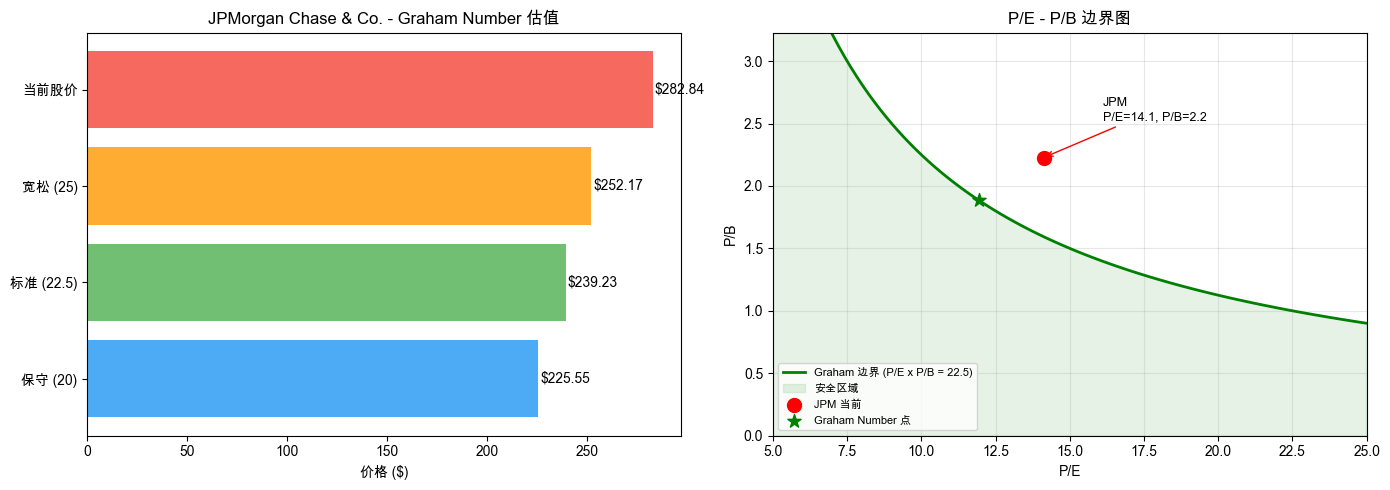

关键洞察：
   左图：比较不同保守程度下的 Graham Number 与当前股价
   右图：绿线下方为格雷厄姆认为的'安全区域'
   JPM 当前位于边界的上方（偏高）


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：Graham Number vs 当前股价
ax1 = axes[0]
gn_conservative = math.sqrt(20.0 * stock.eps * stock.bvps)
gn_standard = math.sqrt(22.5 * stock.eps * stock.bvps)
gn_relaxed = math.sqrt(25.0 * stock.eps * stock.bvps)

bars = ax1.barh(
    ['保守 (20)', '标准 (22.5)', '宽松 (25)', '当前股价'],
    [gn_conservative, gn_standard, gn_relaxed, stock.current_price],
    color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'],
    alpha=0.8
)
ax1.set_xlabel('价格 ($)')
ax1.set_title(f'{stock.name} - Graham Number 估值')

# 添加数值标签
for bar, val in zip(bars, [gn_conservative, gn_standard, gn_relaxed, stock.current_price]):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2, f'${val:.2f}', 
             va='center', fontsize=10)

# 右图：P/E x P/B 可视化
ax2 = axes[1]
pe_values = np.linspace(5, 25, 100)
pb_for_22_5 = 22.5 / pe_values  # P/E * P/B = 22.5 的边界线

ax2.plot(pe_values, pb_for_22_5, 'g-', linewidth=2, label='Graham 边界 (P/E x P/B = 22.5)')
ax2.fill_between(pe_values, 0, pb_for_22_5, alpha=0.1, color='green', label='安全区域')

# 标记当前股票
current_pe = stock.current_price / stock.eps
current_pb = stock.current_price / stock.bvps
ax2.scatter([current_pe], [current_pb], color='red', s=100, zorder=5, label=f'{stock.ticker} 当前')
ax2.annotate(f'{stock.ticker}\nP/E={current_pe:.1f}, P/B={current_pb:.1f}',
             xy=(current_pe, current_pb), xytext=(current_pe+2, current_pb+0.3),
             fontsize=9, arrowprops=dict(arrowstyle='->', color='red'))

# 标记 Graham Number 点
gn_pe = gn_standard / stock.eps
gn_pb = gn_standard / stock.bvps
ax2.scatter([gn_pe], [gn_pb], color='green', s=100, zorder=5, marker='*', label='Graham Number 点')

ax2.set_xlabel('P/E')
ax2.set_ylabel('P/B')
ax2.set_title('P/E - P/B 边界图')
ax2.legend(fontsize=8)
ax2.set_xlim(5, 25)
ax2.set_ylim(0, max(current_pb + 1, 3))
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"关键洞察：")
print(f"   左图：比较不同保守程度下的 Graham Number 与当前股价")
print(f"   右图：绿线下方为格雷厄姆认为的'安全区域'")
print(f"   {stock.ticker} 当前位于边界的{'下方（安全）' if current_pe * current_pb <= 22.5 else '上方（偏高）'}")

## 7. 多公司对比分析

Graham Number 的一个优势是**简单可比**。让我们对比多只股票。

In [8]:
# 对比分析多只股票
tickers = ["JPM", "BAC", "WFC", "GS"]  # 金融股，Graham Number 的理想标的

results_list = []

for t in tickers:
    try:
        s = Stock.from_api(t)
        gn = math.sqrt(22.5 * s.eps * s.bvps) if s.eps > 0 and s.bvps > 10 else None
        
        results_list.append({
            'Ticker': t,
            'Name': s.name,
            'Price': s.current_price,
            'EPS': s.eps,
            'BVPS': s.bvps,
            'P/E': s.current_price / s.eps if s.eps > 0 else None,
            'P/B': s.current_price / s.bvps if s.bvps > 0 else None,
            'Graham#': gn,
            'Premium%': ((gn - s.current_price) / s.current_price * 100) if gn else None,
        })
        print(f"  {t} - {s.name}: done")
    except Exception as e:
        print(f"  {t}: failed - {e}")

df_compare = pd.DataFrame(results_list)

def fmt(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 'N/A'
    return f'{x:.2f}'

print("\n" + "=" * 80)
print("多公司 Graham Number 对比")
print("=" * 80)
print(df_compare.to_string(index=False, float_format=fmt))

  JPM - JPMorgan Chase & Co.: done
  BAC - Bank of America Corporation: done
  WFC - Wells Fargo & Company: done
  GS - The Goldman Sachs Group, Inc.: done

多公司 Graham Number 对比
Ticker                          Name  Price   EPS   BVPS   P/E  P/B  Graham#  Premium%
   JPM          JPMorgan Chase & Co. 282.84 20.03 126.99 14.12 2.23   239.23    -15.42
   BAC   Bank of America Corporation  46.97  3.81  38.44 12.33 1.22    57.41     22.22
   WFC         Wells Fargo & Company  77.19  6.26  53.19 12.33 1.45    86.56     12.14
    GS The Goldman Sachs Group, Inc. 802.89 51.30 356.47 15.65 2.25   641.45    -20.11


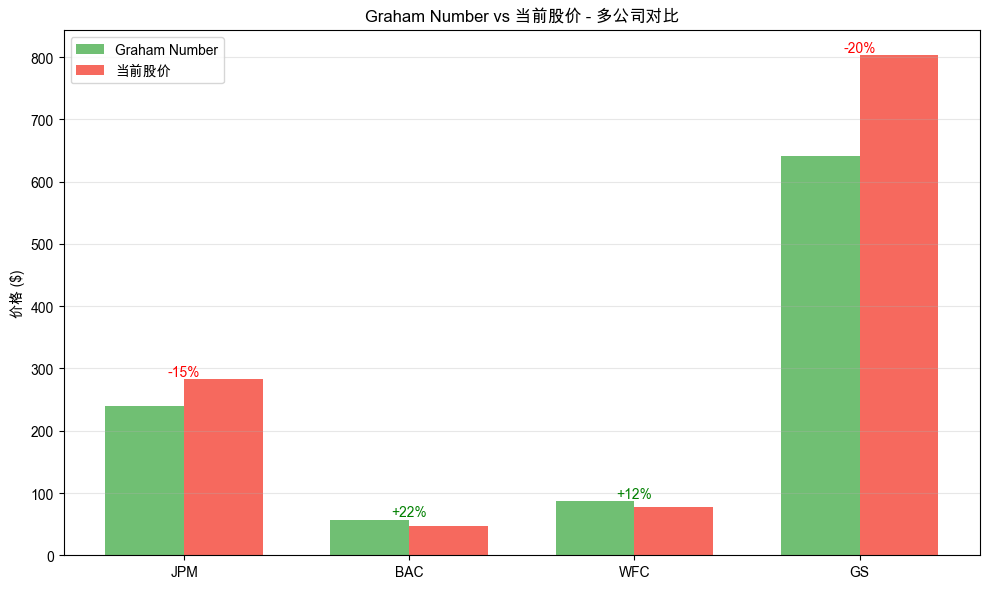

In [9]:
# 可视化多公司对比
fig, ax = plt.subplots(figsize=(10, 6))

valid = df_compare.dropna(subset=['Graham#'])
x = range(len(valid))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], valid['Graham#'], width, 
               label='Graham Number', color='#4CAF50', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], valid['Price'], width, 
               label='当前股价', color='#F44336', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(valid['Ticker'])
ax.set_ylabel('价格 ($)')
ax.set_title('Graham Number vs 当前股价 - 多公司对比')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 添加溢价/折价标签
for i, (_, row) in enumerate(valid.iterrows()):
    if row['Premium%'] is not None:
        color = 'green' if row['Premium%'] > 0 else 'red'
        ax.text(i, max(row['Graham#'], row['Price']) + 5, 
                f"{row['Premium%']:+.0f}%", ha='center', color=color, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. 资产轻公司为什么不适用？

Graham Number 的一个重要局限：**不适用于资产轻公司**。让我们用苹果公司来演示。

In [10]:
# 用 AAPL 演示 Graham Number 在资产轻公司上的问题
stock_aapl = Stock.from_api("AAPL")

print("=" * 60)
print(f"案例：{stock_aapl.name} ({stock_aapl.ticker})")
print("=" * 60)
print(f"当前股价：${stock_aapl.current_price:.2f}")
print(f"EPS：${stock_aapl.eps:.2f}")
print(f"BVPS：${stock_aapl.bvps:.2f}")
print(f"P/E：{stock_aapl.current_price/stock_aapl.eps:.1f}x")
print(f"P/B：{stock_aapl.current_price/stock_aapl.bvps:.1f}x")

print("\n--- 分析 ---")
print(f"BVPS = ${stock_aapl.bvps:.2f}，远低于 $10 阈值")
print("\n原因：苹果长期进行大规模股票回购，导致：")
print("  1. 股东权益被消耗（回购冲减留存收益）")
print("  2. BVPS 被人为压低")
print(f"  3. P/B 比率被人为拔高（目前 {stock_aapl.current_price/stock_aapl.bvps:.1f}x）")

# 尝试运行 Graham Number
result_aapl = engine.run_single(stock_aapl, "graham_number")
print("\n--- 运行结果 ---")
if result_aapl.fair_value and result_aapl.fair_value > 0:
    print(f"Graham Number: ${result_aapl.fair_value:.2f}")
else:
    print(f"不适用：{result_aapl.assessment}")
    for a in result_aapl.analysis:
        print(f"  {a}")

print("\n结论：Graham Number 不适用于以下类型的公司：")
print("  - 大规模回购的科技公司（BVPS 被压低）")
print("  - 无形资产占比高的公司（品牌、专利未计入账面价值）")
print("  - 高增长公司（未来价值远大于当前账面价值）")

案例：Apple Inc. (AAPL)
当前股价：$248.80
EPS：$7.91
BVPS：$6.00
P/E：31.5x
P/B：41.5x

--- 分析 ---
BVPS = $6.00，远低于 $10 阈值

原因：苹果长期进行大规模股票回购，导致：
  1. 股东权益被消耗（回购冲减留存收益）
  2. BVPS 被人为压低
  3. P/B 比率被人为拔高（目前 41.5x）

--- 运行结果 ---
不适用：N/A - Graham Number not applicable: BVPS ($6.00) is below $10 threshold. This typically indicates an asset-light company (e.g., tech with massive buybacks) where the formula is unreliable.
  Cannot calculate: Graham Number not applicable: BVPS ($6.00) is below $10 threshold. This typically indicates an asset-light company (e.g., tech with massive buybacks) where the formula is unreliable.

结论：Graham Number 不适用于以下类型的公司：
  - 大规模回购的科技公司（BVPS 被压低）
  - 无形资产占比高的公司（品牌、专利未计入账面价值）
  - 高增长公司（未来价值远大于当前账面价值）


## 9. A 股案例

In [11]:
# 分析 A 股 - 兴业银行 (601166)
ticker_cn = "601166"
print(f"正在获取 {ticker_cn} (兴业银行) 数据...\n")

try:
    stock_cn = Stock.from_api(ticker_cn)
    
    print("=" * 60)
    print(f"公司：{stock_cn.name} ({stock_cn.ticker})")
    print("=" * 60)
    print(f"当前股价：{stock_cn.current_price:.2f}")
    print(f"每股收益：{stock_cn.eps:.2f}")
    print(f"每股净资产：{stock_cn.bvps:.2f}")
    print(f"P/E：{stock_cn.current_price/stock_cn.eps:.1f}x" if stock_cn.eps > 0 else "P/E: N/A")
    print(f"P/B：{stock_cn.current_price/stock_cn.bvps:.1f}x" if stock_cn.bvps > 0 else "P/B: N/A")
    
    # 运行 Graham Number
    result_cn = engine.run_single(stock_cn, "graham_number")
    
    if result_cn.fair_value:
        print(f"\nGraham Number 估值结果")
        print(f"   Graham Number：{result_cn.fair_value:.2f}")
        print(f"   溢价/折价：{result_cn.premium_discount:+.1f}%")
        print(f"   评估：{result_cn.assessment}")
        if result_cn.fair_value_range:
            print(f"   保守：{result_cn.fair_value_range.low:.2f}")
            print(f"   宽松：{result_cn.fair_value_range.high:.2f}")
    else:
        print(f"\n估值失败：{result_cn.error}")
        
except Exception as e:
    print(f"获取数据失败：{e}")
    print("\n提示：确保已安装 AKShare: pip install valueinvest[ashare]")

正在获取 601166 (兴业银行) 数据...

公司：兴业银行 (601166)
当前股价：18.69
每股收益：3.46
每股净资产：42.61
P/E：5.4x
P/B：0.4x

Graham Number 估值结果
   Graham Number：57.59
   溢价/折价：+208.2%
   评估：Undervalued
   保守：54.30
   宽松：60.71


## 10. Graham Number 的局限性和最佳实践

### 局限性

1. **仅适用于资产重型公司**
   - BVPS < $10 的公司公式失效
   - 不适合大量回购或无形资产占比高的企业

2. **忽略增长**
   - 公式完全不考虑未来增长潜力
   - 对稳定增长的公司可能过于保守

3. **单一时点快照**
   - 只使用当前 EPS 和 BVPS
   - 不考虑盈利波动或周期性

4. **22.5 乘数的假设**
   - P/E=15 和 P/B=1.5 的上限是经验值
   - 不同市场环境可能需要调整

### 最佳实践

1. **选对标的**
   - 优先用于银行、保险、传统制造业
   - 避免用于科技、消费品牌等资产轻公司

2. **作为筛选工具**
   - Graham Number 更适合初筛，而非精确估值
   - 股价低于 Graham Number 不一定值得买

3. **结合其他方法**
   - Graham Number + DCF（结合增长预期）
   - Graham Number + Piotroski F-Score（检查财务健康）

4. **关注趋势**
   - 观察 EPS 和 BVPS 的历史趋势
   - 盈利下降的公司 Graham Number 会持续走低

In [12]:
# 综合分析：将 Graham Number 与其他估值方法结合
print(f"综合估值分析 - {stock.name}")
print("=" * 60)

results_all = engine.run_all(stock)

# 筛选有效结果
valid_results = [(r.method, r.fair_value, r.premium_discount, r.confidence) 
                 for r in results_all if r.fair_value and r.fair_value > 0]

if valid_results:
    df_results = pd.DataFrame(valid_results, 
                              columns=['方法', '内在价值', '溢价/折价%', '置信度'])
    
    def fmt_result(x):
        if isinstance(x, str):
            return x
        if isinstance(x, float):
            return f'{x:.2f}'
        return str(x)
    
    print(df_results.to_string(index=False, float_format=fmt_result))
    
    avg_value = np.mean([r[1] for r in valid_results])
    print(f"\n平均估值：${avg_value:.2f}")
    print(f"当前股价：${stock.current_price:.2f}")
    print("Graham Number 在综合分析中的角色：提供一个保守的价值下限")

综合估值分析 - JPMorgan Chase & Co.
                 方法   内在价值  溢价/折价%    置信度
      Graham Number 239.23  -15.40   High
     Graham Formula 224.49  -20.60   High
  EPV (Zero Growth) 162.98  -42.40    Low
      Two-Stage DDM  83.88  -70.30 Medium
          PEG Ratio  50.08  -82.30 Medium
               GARP 231.46  -18.20    Low
         Rule of 40 282.84    0.00 Medium
      P/B Valuation 224.36  -20.70   High
    Residual Income 188.36  -33.40 Medium
      Magic Formula 218.78  -22.60 Medium
     Owner Earnings 225.17  -20.40 Medium
          EV/EBITDA 274.15   -3.10    Low
     Altman Z-Score 282.84    0.00    Low
       SBC Analysis 282.84    0.00 Medium
Value Trap Detector 282.84    0.00 Medium
  Piotroski F-Score 282.84    0.00 Medium
        PE Relative 209.81  -25.80    Low
        PB Relative 184.45  -34.80    Low
    Beneish M-Score 282.84    0.00    Low

平均估值：$221.80
当前股价：$282.84
Graham Number 在综合分析中的角色：提供一个保守的价值下限


## 11. 总结

### 关键要点

1. **Graham Number = sqrt(22.5 x EPS x BVPS)**
   - 来自 P/E <= 15 且 P/B <= 1.5 的约束
   - 为防御型投资者提供保守的价格上限

2. **适用条件**
   - EPS > 0，BVPS > $10
   - 资产重型、盈利稳定的成熟公司
   - 银行、保险、传统制造业

3. **不适用场景**
   - 大规模回购的科技公司
   - 无形资产占比高的企业
   - 高增长公司

4. **使用建议**
   - 作为初筛工具，不作为唯一估值标准
   - 结合 DCF、相对估值等其他方法
   - 关注 EPS 和 BVPS 的趋势

---

**参考资料**：
- [ValueInvest GitHub](https://github.com/wangzhe3224/valueinvest)
- 《聪明的投资者》- Benjamin Graham
- 《证券分析》- Benjamin Graham & David Dodd